**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
Erick Gabriel Santiago Suenaga

# Tarea 2: Preprocesamiento de Datos

El objetivo de esta tarea es explorar el dataset Breast Cancer Wisconsin, aplicar dos técnicas de preprocesamiento y comparar gráficamente cómo se ven los datos antes y después de cada una.


**Técnicas elegidas**

| Técnica | Tipo | Qué se hará |
|---|---|---|
| Limpieza de datos | Limpieza | Revisar tipos, duplicados, valores faltantes, quitar el identificador |
| PCA (Análisis de Componentes Principales) | Reducción de dimensionalidad | Pasar de 9 características a 2 componentes principales |

**Contenido**

1. Preparación del entonro
2. Carga del dataset
3. Análisis exploratorio (EDA)
4. Limpieza de datos (con gráficas antes/después)
5. Reducción de dimensionalidad con PCA (con gráficas antes/después)
6. Conclusiones
7. Referencias

## 1. Preparación del entorno

Usamos `pandas` y `numpy` para los datos, `matplotlib` y `seaborn` para las gráficas, de `scikit-learn` se toma la herramienta de `PCA` para la reducción de dimensionalidad.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuración de visualización para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 20)

# Colores fijos para el diagnóstico, para que sean iguales en todas las gráficas
COLORES = {"Benigno": "#52A7F2", "Maligno": "#F25252"}
ORDEN = ["Benigno", "Maligno"]

## 2. Carga del dataset

Según el archivo `.names`:

- **Fuente:** Dr. William H. Wolberg, University of Wisconsin Hospitals, Madison (donado por Olvi Mangasarian, 1992).
- **Unidad de observación:** una muestra de tejido mamario (biopsia por aspiración con aguja fina).
- **699 instancias**, 9 características numéricas (puntajes de 1 a 10), un identificador de muestra y la clase (`2` = Benigno, `4` = Maligno).
- **Valores faltantes:** 16, marcados con `?`.

Los nombres de las columnas se toman de la sección 7 del archivo `.names`.

In [2]:
RUTA = "breast-cancer-wisconsin.data"

columnas = [
    "id",                          # Id
    "clump_thickness",             # Grosor del grupo de células
    "uniformity_cell_size",        # Uniformidad del tamaño celular
    "uniformity_cell_shape",       # Uniformidad de la forma celular
    "marginal_adhesion",           # Adhesión marginal
    "single_epithelial_cell_size", # Tamaño de célula epitelial individual
    "bare_nuclei",                 # Núcleos desnudos
    "bland_chromatin",             # Cromatina blanda
    "normal_nucleoli",             # Nucléolos normales
    "mitoses",                     # Mitosis
    "class",                       # 2 = Benigno, 4 = Maligno
]

# Las 9 columnas que describen la muestra (todo menos id y class)
caracteristicas = columnas[1:-1]

# df_raw es la copia original, no se modifica, es para poder comparar "antes" vs "después"
df_raw = pd.read_csv(RUTA, header=None, names=columnas, na_values="?")
df_raw.head()

,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


## 3. Análisis exploratorio (EDA)



### 3.1 Estructura general

In [3]:
print(f"Registros: {df_raw.shape[0]}  |  Atributos: {df_raw.shape[1]}")
df_raw.info()

Registros: 699  |  Atributos: 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           699 non-null    int64  
 1   clump_thickness              699 non-null    int64  
 2   uniformity_cell_size         699 non-null    int64  
 3   uniformity_cell_shape        699 non-null    int64  
 4   marginal_adhesion            699 non-null    int64  
 5   single_epithelial_cell_size  699 non-null    int64  
 6   bare_nuclei                  683 non-null    float64
 7   bland_chromatin              699 non-null    int64  
 8   normal_nucleoli              699 non-null    int64  
 9   mitoses                      699 non-null    int64  
 10  class                        699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


Existen 699 registros y 11 atributos (columnas), como dice la documentación. Todas las columnas son enteras excepto `bare_nuclei`, que aparece como `float64` debido a los datos faltantes.

### 3.2 Estadísticas descriptivas

In [4]:
df_raw[caracteristicas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
clump_thickness,699.0,4.42,2.82,1.0,2.0,4.0,6.0,10.0
uniformity_cell_size,699.0,3.13,3.05,1.0,1.0,1.0,5.0,10.0
uniformity_cell_shape,699.0,3.21,2.97,1.0,1.0,1.0,5.0,10.0
marginal_adhesion,699.0,2.81,2.86,1.0,1.0,1.0,4.0,10.0
single_epithelial_cell_size,699.0,3.22,2.21,1.0,2.0,2.0,4.0,10.0
bare_nuclei,683.0,3.54,3.64,1.0,1.0,1.0,6.0,10.0
bland_chromatin,699.0,3.44,2.44,1.0,2.0,3.0,5.0,10.0
normal_nucleoli,699.0,2.87,3.05,1.0,1.0,1.0,4.0,10.0
mitoses,699.0,1.59,1.72,1.0,1.0,1.0,1.0,10.0


Todas las características están en la misma escala (mínimo 1, máximo 10). Las medianas son bajas en casi todas (por ejemplo, la mediana de `mitoses` es 1) y las medias quedan por encima de las medianas, lo que indica distribuciones con cola hacia valores altos.

### 3.3 Distribución de la clase

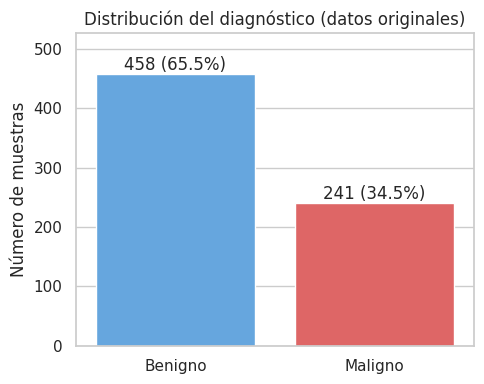

In [5]:
etiqueta = df_raw["class"].map({2: "Benigno", 4: "Maligno"})
conteo = etiqueta.value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=etiqueta, order=ORDEN, hue=etiqueta, palette=COLORES, legend=False, ax=ax)
for i, nombre in enumerate(ORDEN):
    ax.text(i, conteo[nombre] + 6, f"{conteo[nombre]} ({conteo[nombre] / len(etiqueta):.1%})", ha="center")
ax.set_title("Distribución del diagnóstico (datos originales)")
ax.set_xlabel("")
ax.set_ylabel("Número de muestras")
ax.set_ylim(0, conteo.max() * 1.15)
plt.tight_layout()
plt.show()

Hay 458 muestras benignas (65.5 %) y 241 malignas (34.5 %), igual que en la documentación. Las clases están desbalanceadas, aunque no de forma extrema.

### 3.4 Distribución de cada característica

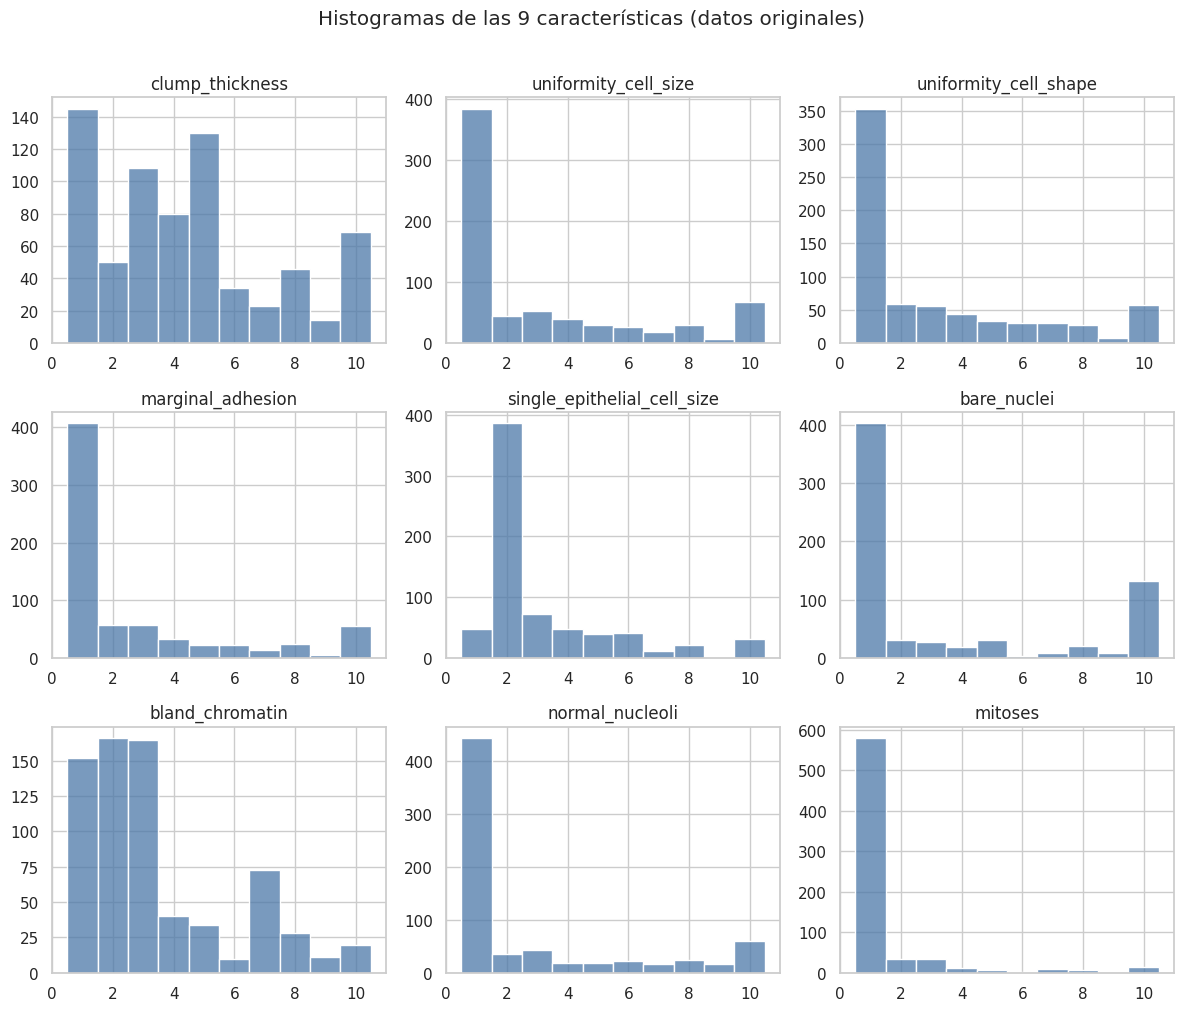

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, c in zip(axes.ravel(), caracteristicas):
    sns.histplot(df_raw[c].dropna(), discrete=True, color="#4C78A8", ax=ax)
    ax.set_title(c)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.suptitle("Histogramas de las 9 características (datos originales)", y=1.01)
plt.tight_layout()
plt.show()

Como los valores son enteros del 1 al 10, los histogramas son de barras discretas. Casi todas las variables se concentran en valores bajos, con el valor 1 muy dominante (sobre todo en `mitoses`, `normal_nucleoli`, `marginal_adhesion` y `uniformity_cell_size`), y una cola larga hacia el 10. `clump_thickness` es la más repartida a lo largo de la escala.

### 3.5 Características según el diagnóstico

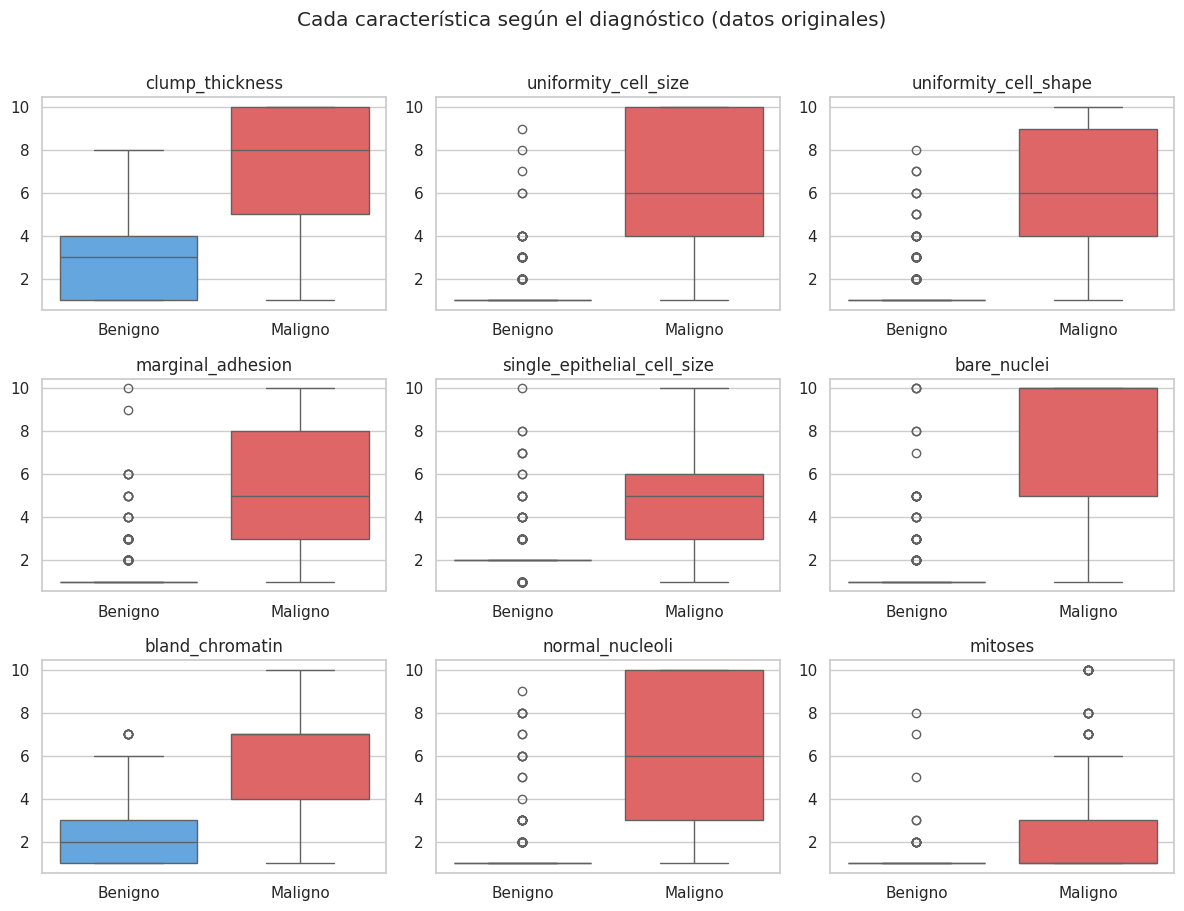

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, c in zip(axes.ravel(), caracteristicas):
    sns.boxplot(x=etiqueta, y=df_raw[c], order=ORDEN, hue=etiqueta,
                palette=COLORES, legend=False, ax=ax)
    ax.set_title(c)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.suptitle("Cada característica según el diagnóstico (datos originales)", y=1.01)
plt.tight_layout()
plt.show()

En las 9 características las muestras malignas tienen valores más altos que las benignas. La diferencia es muy clara en `uniformity_cell_size`, `uniformity_cell_shape` y `bare_nuclei`, y más discreta en `mitoses`, donde casi todo el grupo benigno vale 1. Esto sugiere que las variables sí contienen información útil para distinguir los dos grupos.

### 3.6 Correlaciones entre características

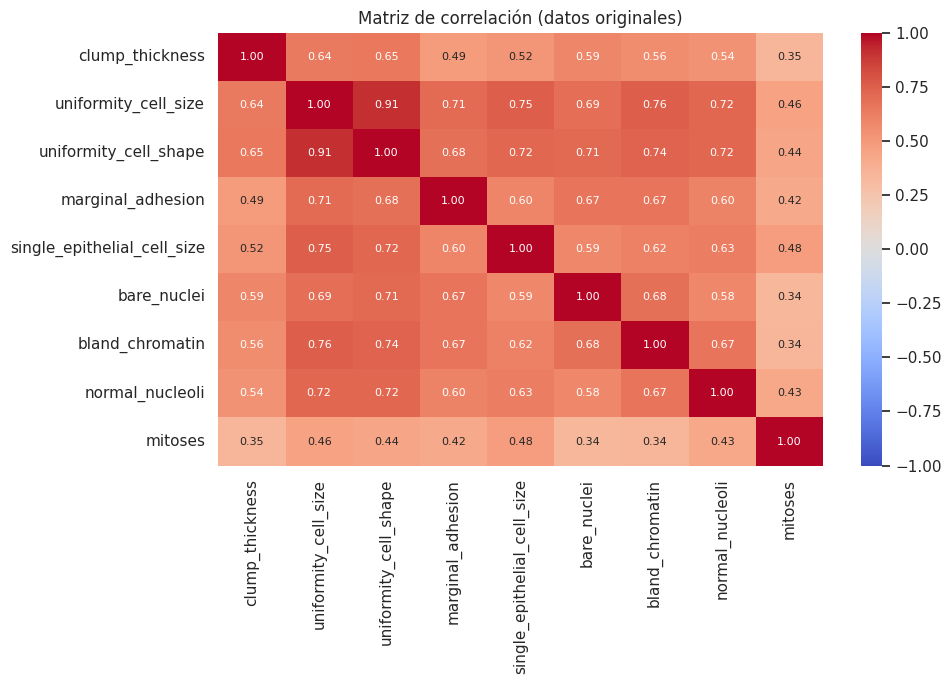

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df_raw[caracteristicas].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, annot_kws={"size": 8}, ax=ax)
ax.set_title("Matriz de correlación (datos originales)")
plt.tight_layout()
plt.show()

Todas las correlaciones son positivas, la más alta se encuentra entre `uniformity_cell_size` y `uniformity_cell_shape` (cerca de 0.91), las dos se relacionan bastante también (entre 0.72 y 0.76) con `bland_chromatin`, `single_epithelial_cell_size` y `normal_nucleoli`. Se puede utilizar esta redundancia entre variables para resumir la información en menos dimensiones con PCA.

## 4. Limpieza de datos

Se trabaja sobre una copia (`df_limpio`) y se deja `df_raw` sin modificar. Primero se revisa tipos y duplicados, después faltantes (para que registros repetidos no pesen en el cálculo de la mediana) y al final se quitan columnas sin información.

In [9]:
df_limpio = df_raw.copy()

### 4.1 Tipos de datos y rangos

In [10]:
print(df_limpio.dtypes.to_frame("tipo"))

# Verificamos que las 9 características respeten el rango documentado (1 a 10)
fuera_de_rango = ((df_limpio[caracteristicas] < 1) | (df_limpio[caracteristicas] > 10)).sum().sum()
print(f"\nValores fuera del rango 1-10: {fuera_de_rango}")
print("Valores distintos en class:", sorted(df_limpio["class"].unique()))

                                tipo
id                             int64
clump_thickness                int64
uniformity_cell_size           int64
uniformity_cell_shape          int64
marginal_adhesion              int64
single_epithelial_cell_size    int64
bare_nuclei                  float64
bland_chromatin                int64
normal_nucleoli                int64
mitoses                        int64
class                          int64

Valores fuera del rango 1-10: 0
Valores distintos en class: [np.int64(2), np.int64(4)]


**Lectura.**

- `bare_nuclei` es `float64` únicamente porque tiene valores faltantes (`NaN`); en realidad es un puntaje entero. Lo convertiremos a entero cuando ya no tenga faltantes.
- `id` es un número entero, pero **no es una medida**: solo identifica la muestra.
- `class` es un código (2 y 4), no una cantidad; lo recodificaremos a texto.
- No hay valores fuera del rango 1 a 10.

### 4.2 Duplicados

In [11]:
n_exactos = df_limpio.duplicated().sum()
print(f"Registros completamente idénticos (incluyendo id): {n_exactos}")

# Mostramos ambas copias de cada registro repetido
df_limpio[df_limpio.duplicated(keep=False)].sort_values("id")

Registros completamente idénticos (incluyendo id): 8


,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
272,320675,3,3,5,2,3,10.0,7,1,1,4
267,320675,3,3,5,2,3,10.0,7,1,1,4
684,466906,1,1,1,1,2,1.0,1,1,1,2
683,466906,1,1,1,1,2,1.0,1,1,1,2
314,704097,1,1,1,1,1,1.0,2,1,1,2
338,704097,1,1,1,1,1,1.0,2,1,1,2
42,1100524,6,10,10,2,8,10.0,7,3,3,4
253,1100524,6,10,10,2,8,10.0,7,3,3,4
62,1116116,9,10,10,1,10,8.0,3,3,1,4
254,1116116,9,10,10,1,10,8.0,3,3,1,4


In [12]:
print(f"Registros con un id que ya apareció antes: {df_limpio['id'].duplicated().sum()}")
print(f"Registros cuyas 9 medidas coinciden con otro registro (sin mirar el id): "
      f"{df_limpio[caracteristicas].duplicated().sum()}")

Registros con un id que ya apareció antes: 54
Registros cuyas 9 medidas coinciden con otro registro (sin mirar el id): 236


- Hay 8 registros idénticos en todo, incluido el `id`, son copias exactas de una misma muestra y se eliminan.
- Hay más `id` repetidos (54 registros con un `id` que ya había aparecido) que registros idénticos: 8 son copias exactas y las otras 46 tienen medidas distintas. Según el `.names`, las muestras llegaron en distintos momentos, y un mismo paciente pudo tener más de una muestra con mediciones distintas. Si el `id` se repite pero las medidas cambian, no es un duplicado y se conserva.
- Muchos registros coinciden en sus 9 medidas aunque sean de pacientes distintos.

In [13]:
df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)
print(f"Registros antes: {len(df_raw)}  |  después: {len(df_limpio)}")

Registros antes: 699  |  después: 691


### 4.3 Valores faltantes

In [14]:
faltantes = df_limpio.isna().sum().to_frame("faltantes")
faltantes["porcentaje"] = (faltantes["faltantes"] / len(df_limpio) * 100).round(2)
print(faltantes[faltantes["faltantes"] > 0])

print("\nDiagnóstico de las filas con faltantes:")
print(df_limpio.loc[df_limpio["bare_nuclei"].isna(), "class"].map({2: "Benigno", 4: "Maligno"}).value_counts())

             faltantes  porcentaje
bare_nuclei         16        2.32

Diagnóstico de las filas con faltantes:
class
Benigno    14
Maligno     2
Name: count, dtype: int64


Los 16 datos faltantes están todos en `bare_nuclei` (cerca del 2.3 % de los registros) y 14 de los 16 registros son benignos.

Se podrían eliminar los registros al ser poco representativos en comparación a la totalidad de los datos, o también se podría rellenar estos valores (imputación) con la mediana de la columna, ya que la mediana no se distorcionaría.

En este caso se eligió la imputación con la mediana porque `bare_nuclei` es un puntaje entero y la mediana es un valor real de esa escala. La parte que podría ser negativa es que la imputación agrega valores "inventados", en este caso como son solo 16 registros el efecto es pequeño.

In [15]:
mediana = df_limpio["bare_nuclei"].median()
print(f"Mediana de bare_nuclei: {mediana}")

df_limpio["bare_nuclei"] = df_limpio["bare_nuclei"].fillna(mediana)
df_limpio["bare_nuclei"] = df_limpio["bare_nuclei"].astype(int)   # ya sin NaN, vuelve a entero

print("Faltantes restantes:", int(df_limpio.isna().sum().sum()))
print("Tipo de bare_nuclei:", df_limpio["bare_nuclei"].dtype)

Mediana de bare_nuclei: 1.0
Faltantes restantes: 0
Tipo de bare_nuclei: int64


### 4.4 Columnas sin información y recodificación de la clase

- `id` solo identifica la muestra no describe el tejido y no debe entrar al PCA (haría que el "número de paciente" parezca una característica).
- `class` pasa de códigos `2/4` a texto `benigno/maligno` en una columna nueva llamada `diagnostico`, más fácil de leer en las gráficas.

In [16]:
df_limpio["diagnostico"] = df_limpio["class"].map({2: "Benigno", 4: "Maligno"})
df_limpio = df_limpio.drop(columns=["id", "class"])

print("Forma final:", df_limpio.shape)
print("Faltantes en toda la tabla:", int(df_limpio.isna().sum().sum()))
df_limpio.head()

Forma final: (691, 10)
Faltantes en toda la tabla: 0


,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,diagnostico
0,5,1,1,1,2,1,3,1,1,Benigno
1,5,4,4,5,7,10,3,2,1,Benigno
2,3,1,1,1,2,2,3,1,1,Benigno
3,6,8,8,1,3,4,3,7,1,Benigno
4,4,1,1,3,2,1,3,1,1,Benigno


Al quitar `id` sí aparecen registros con las 9 medidas iguales. Son coincidencias entre muestras distintas y se conservan.

### 4.5 Comparación antes y después de la limpieza

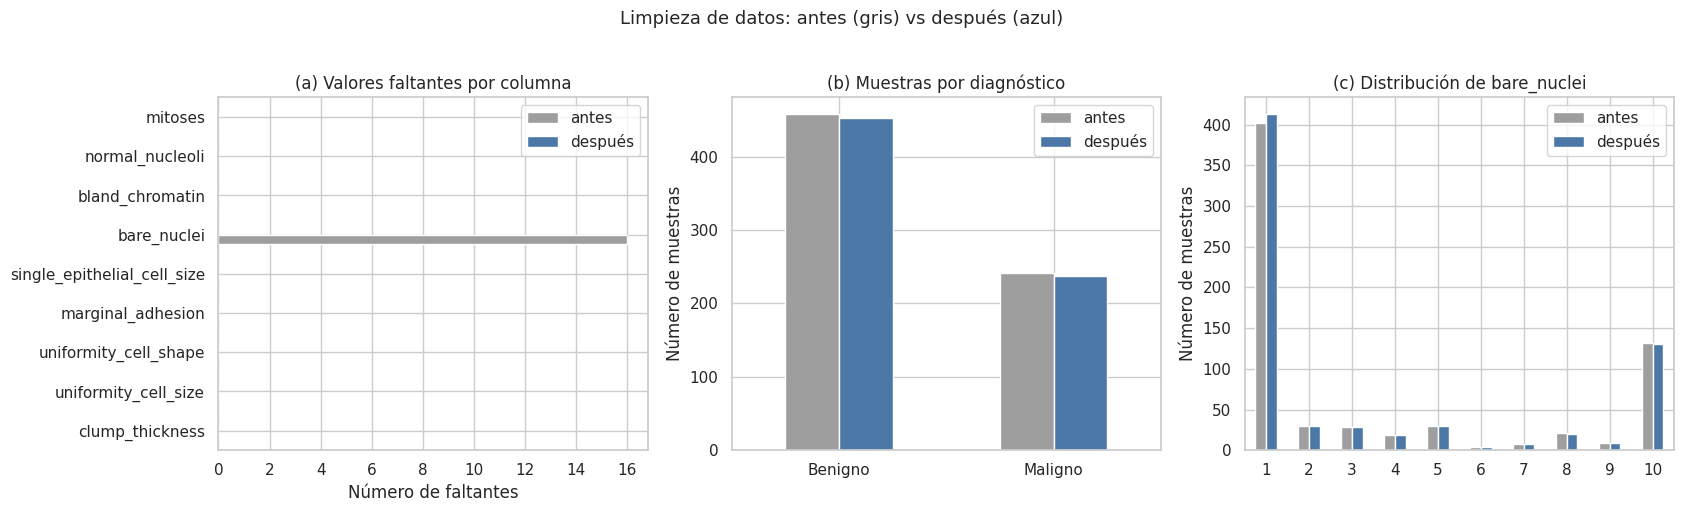

Antes:   699 registros x 11 columnas
Después: 691 registros x 10 columnas


In [17]:
GRIS, AZUL = "#9E9E9E", "#4C78A8"

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) Valores faltantes por columna
nulos = pd.DataFrame({
    "antes": df_raw[caracteristicas].isna().sum(),
    "después": df_limpio[caracteristicas].isna().sum(),
})
nulos.plot.barh(ax=axes[0], color=[GRIS, AZUL])
axes[0].set_title("(a) Valores faltantes por columna")
axes[0].set_xlabel("Número de faltantes")

# (b) Muestras por diagnóstico
clases = pd.DataFrame({
    "antes": df_raw["class"].map({2: "Benigno", 4: "Maligno"}).value_counts(),
    "después": df_limpio["diagnostico"].value_counts(),
}).loc[ORDEN]
clases.plot.bar(ax=axes[1], rot=0, color=[GRIS, AZUL])
axes[1].set_title("(b) Muestras por diagnóstico")
axes[1].set_xlabel("")
axes[1].set_ylabel("Número de muestras")

# (c) Distribución de bare_nuclei
bn = pd.DataFrame({
    "antes": df_raw["bare_nuclei"].value_counts().sort_index(),
    "después": df_limpio["bare_nuclei"].value_counts().sort_index(),
})
bn.index = bn.index.astype(int)
bn.plot.bar(ax=axes[2], rot=0, color=[GRIS, AZUL])
axes[2].set_title("(c) Distribución de bare_nuclei")
axes[2].set_xlabel("")
axes[2].set_ylabel("Número de muestras")

plt.suptitle("Limpieza de datos: antes (gris) vs después (azul)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Antes:   {df_raw.shape[0]} registros x {df_raw.shape[1]} columnas")
print(f"Después: {df_limpio.shape[0]} registros x {df_limpio.shape[1]} columnas")

- **(a)** Antes, `bare_nuclei` tenía 16 faltantes; después ya no queda ninguno en ninguna columna.
- **(b)** Al eliminar los 8 registros duplicados exactos, el número de muestras baja un poco en cada clase (de 458 a 453 benignas y de 241 a 238 malignas). La proporción entre clases casi no cambia.
- **(c)** La imputación con la mediana agrega los 16 datos faltantes en el valor 1, la mediana de la columna, por eso esa barra crece (de 402 a 413) y las demás casi no se mueven (las pequeñas bajas en 8 y 10 se deben a los duplicados eliminados).

La tabla pasa de 699 × 11 a 691 × 10 (menos 8 registros repetidos y menos la columna `id`, con `class` sustituida por `diagnostico`).

## 5. Reducción de dimensionalidad con PCA

### 5.1 Idea general

Tenemos 9 características, y vimos que están bastante correlacionadas entre sí. El **PCA** busca ejes nuevos, llamados **componentes principales (PC)**, que son combinaciones de las variables originales y cumplen que:

- **PC1** es la dirección en la que los datos varían más; **PC2** es la siguiente dirección con más variación, y así sucesivamente.
- Los componentes son **independientes entre sí** (no están correlacionados).

Si los primeros componentes concentran casi toda la variación, podemos quedarnos con ellos y descartar el resto, perdiendo poca información. Aquí reduciremos de 9 dimensiones a 2, lo que además permite graficar los datos en un plano.

El PCA es una técnica no supervisada, no usa el diagnóstico. Solo lo usamos después para colorear los puntos.

### 5.2 Estandarización

El PCA se basa en varianzas, así que es importante que todas las variables estén en la misma escala. Aquí todas van de 1 a 10, pero la práctica habitual es estandarizar de todas formas (restar la media y dividir entre la desviación estándar) para que ninguna variable domine solo porque tenga más dispersión.

In [18]:
X = df_limpio[caracteristicas]

scaler = StandardScaler()
X_est = pd.DataFrame(scaler.fit_transform(X), columns=caracteristicas)

comparacion = pd.DataFrame({
    "media (antes)": X.mean(),
    "desv. est. (antes)": X.std(),
    "media (después)": X_est.mean(),
    "desv. est. (después)": X_est.std(),
}).round(2)
comparacion

,media (antes),desv. est. (antes),media (después),desv. est. (después)
clump_thickness,4.43,2.82,-0.0,1.0
uniformity_cell_size,3.13,3.04,0.0,1.0
uniformity_cell_shape,3.20,2.96,0.0,1.0
marginal_adhesion,2.82,2.87,0.0,1.0
single_epithelial_cell_size,3.21,2.20,0.0,1.0
bare_nuclei,3.48,3.62,0.0,1.0
bland_chromatin,3.44,2.44,0.0,1.0
normal_nucleoli,2.88,3.07,0.0,1.0
mitoses,1.59,1.72,0.0,1.0


Antes de estandarizar, las variables tenían medias y dispersiones distintas. Después, todas tienen media 0 y desviación estándar 1.

### 5.3 Aplicar el PCA y ver cuánta varianza explica cada componente

Primero calculamos los 9 componentes para ver cuánta información aporta cada uno y decidir con cuántos quedarnos.

In [19]:
pca_completo = PCA()
componentes = pca_completo.fit_transform(X_est)     # 691 filas x 9 componentes

var_exp = pca_completo.explained_variance_ratio_
var_acum = np.cumsum(var_exp)
nombres_pc = [f"PC{i + 1}" for i in range(len(var_exp))]

tabla_var = pd.DataFrame({
    "varianza explicada": var_exp.round(3),
    "acumulada": var_acum.round(3),
}, index=nombres_pc)
tabla_var

,varianza explicada,acumulada
PC1,0.656,0.656
PC2,0.086,0.742
PC3,0.060,0.802
PC4,0.052,0.854
PC5,0.041,0.895
PC6,0.033,0.928
PC7,0.033,0.961
PC8,0.029,0.990
PC9,0.010,1.000


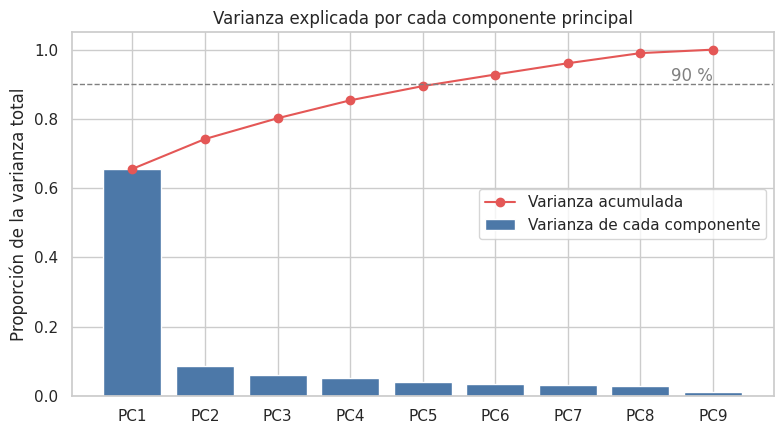

PC1 explica 65.6%; PC1 + PC2 explican 74.2%.
Para conservar al menos 90 % de la varianza harían falta 6 componentes.


In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(nombres_pc, var_exp, color=AZUL, label="Varianza de cada componente")
ax.plot(nombres_pc, var_acum, color="#E45756", marker="o", label="Varianza acumulada")
ax.axhline(0.90, color="gray", linestyle="--", linewidth=1)
ax.text(len(nombres_pc) - 1, 0.91, "90 %", ha="right", color="gray")
ax.set_ylabel("Proporción de la varianza total")
ax.set_ylim(0, 1.05)
ax.set_title("Varianza explicada por cada componente principal")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

n_90 = int(np.argmax(var_acum >= 0.90) + 1)
print(f"PC1 explica {var_exp[0]:.1%}; PC1 + PC2 explican {var_acum[1]:.1%}.")
print(f"Para conservar al menos 90 % de la varianza harían falta {n_90} componentes.")

PC1 por sí solo explica casi dos tercios de la variación total (65.6 %), y PC2 aporta un 8.6 % más, para un total de 74.2 % con los dos primeros. Los componentes siguientes aportan cada vez menos. Es un reflejo de las fuertes correlaciones vista en el EDA, las 9 variables dicen lo mismo.

Haciendo uso de solo 2 componentes es posible graficar en un plano, a costa de perder alrededor del 26 % de la varianza. Si el objetivo fuera conservar la mayor parte de la información (por ejemplo, ≥ 90 %) tendríamos que quedarnos con 6 componentes.

In [21]:
# Quedarse con 2 componentes = tomar las 2 primeras columnas (equivale a PCA(n_components=2))
df_pca = pd.DataFrame(componentes[:, :2], columns=["PC1", "PC2"])
df_pca["diagnostico"] = df_limpio["diagnostico"].values

print("Forma antes del PCA :", X.shape)
print("Forma después del PCA:", df_pca[["PC1", "PC2"]].shape)
print(f"Varianza total conservada: {var_acum[1]:.1%}")
df_pca.head()

Forma antes del PCA : (691, 9)
Forma después del PCA: (691, 2)
Varianza total conservada: 74.2%


,PC1,PC2,diagnostico
0,-1.460400,-0.112622,Benigno
1,1.468035,-0.528386,Benigno
2,-1.582963,-0.075107,Benigno
3,1.505021,-0.559864,Benigno
4,-1.334316,-0.094751,Benigno


### 5.4 Signficado de cada componente

Cada componente es una combinación de las variables originales. Los pesos indican cuánto contribuye cada variable a cada componente.

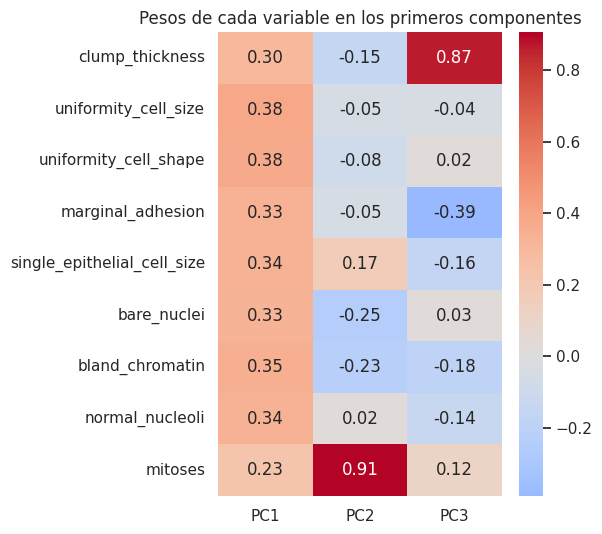

In [22]:
cargas = pd.DataFrame(pca_completo.components_[:3].T,
                      index=caracteristicas, columns=["PC1", "PC2", "PC3"])

fig, ax = plt.subplots(figsize=(6, 5.5))
sns.heatmap(cargas, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Pesos de cada variable en los primeros componentes")
plt.tight_layout()
plt.show()

- **PC1:** todas las variables aportan con peso positivo y parecido (entre 0.23 y 0.38). PC1 funciona como un índice general de qué tan "alteradas" están las características de la muestra: valores altos en casi todo dan un PC1 alto.
- **PC2:** está dominado por `mitoses` (0.91), con contribuciones menores y negativas de `bare_nuclei` y `bland_chromatin`. Captura la parte de la variación que es propia de la mitosis y que el índice general no explica.
- **PC3:** está dominado por `clump_thickness` (0.87).

### 5.5 Comparación antes y después del PCA

Antes se tenía 9 variables, y solo se pueden graficar 2 a la vez. Como ejemplo se toma `uniformity_cell_size` y `bare_nuclei`. Como los puntajes son enteros, muchos puntos coinciden exactamente; para poder verlos, se les suma un pequeño ruido aleatorio solo en la gráfica. Los datos no se modifican.

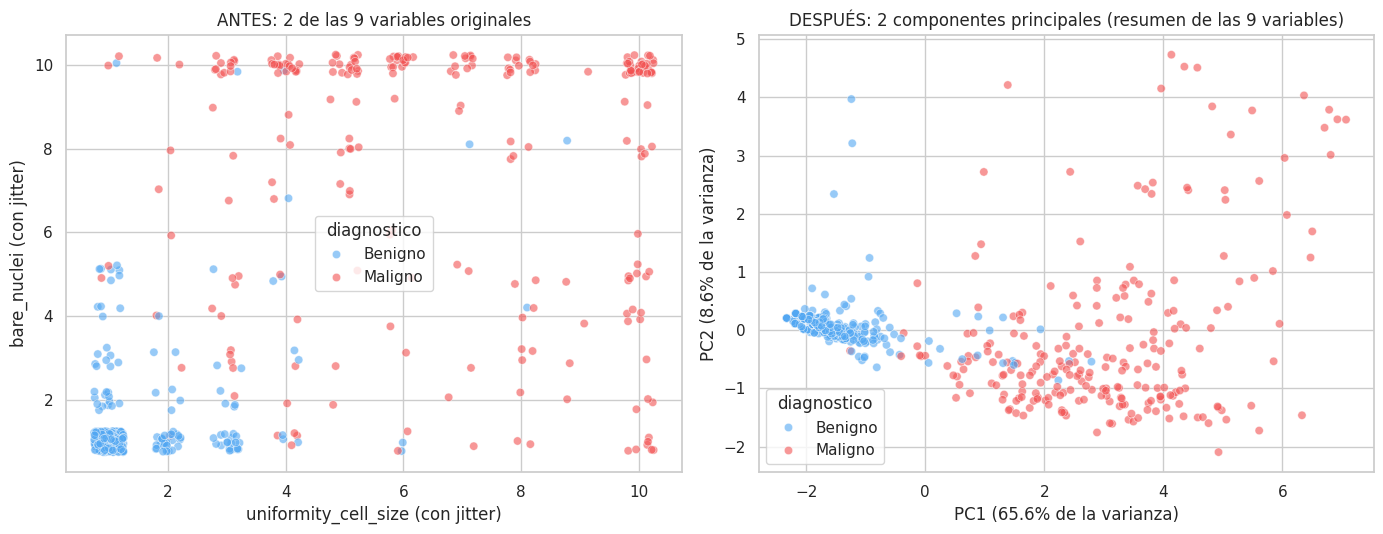

In [23]:
rng = np.random.default_rng(42)

def jitter(serie, amplitud=0.25):
    """Solo para graficar: separa un poco los puntos que coinciden exactamente."""
    return serie + rng.uniform(-amplitud, amplitud, len(serie))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ANTES: 2 de las 9 variables originales
sns.scatterplot(x=jitter(df_limpio["uniformity_cell_size"]),
                y=jitter(df_limpio["bare_nuclei"]),
                hue=df_limpio["diagnostico"], hue_order=ORDEN, palette=COLORES,
                alpha=0.6, ax=axes[0])
axes[0].set_xlabel("uniformity_cell_size (con jitter)")
axes[0].set_ylabel("bare_nuclei (con jitter)")
axes[0].set_title("ANTES: 2 de las 9 variables originales")

# DESPUÉS: los 2 primeros componentes principales
sns.scatterplot(data=df_pca, x="PC1", y="PC2",
                hue="diagnostico", hue_order=ORDEN, palette=COLORES,
                alpha=0.6, ax=axes[1])
axes[1].set_xlabel(f"PC1 ({var_exp[0]:.1%} de la varianza)")
axes[1].set_ylabel(f"PC2 ({var_exp[1]:.1%} de la varianza)")
axes[1].set_title("DESPUÉS: 2 componentes principales (resumen de las 9 variables)")

plt.tight_layout()
plt.show()

In [24]:
# Posición promedio de cada grupo sobre los componentes
df_pca.groupby("diagnostico")[["PC1", "PC2"]].mean().round(2)

,PC1,PC2
diagnostico,,
Benigno,-1.57,0.08
Maligno,3.00,-0.15


- **Antes:** con solo dos variables originales los puntos forman una cuadrícula, porque los valores son enteros, y solo vemos una parte de la información (2 de 9 variables). Las clases se distinguen, pero con mezcla en la zona de valores bajos.
- **Después:** cada punto resume las 9 variables. Los dos grupos se ordenan sobre el eje **PC1**: las muestras benignas se agrupan compactas a un lado y las malignas se extienden hacia el otro, con más dispersión. Esto es coherente con lo visto en el EDA (las malignas tienen valores altos en casi todo). Sobre PC2 hay menos diferencia entre grupos, y hay cierta mezcla en la zona central. El PCA no usó el diagnóstico, pero aun así la estructura de los datos separa buena parte de los casos.
- La reducción tiene un costo: se conserva el 74.2 % de la varianza, y los ejes ya no son variables clínicas directamente interpretables como antes.

Redundancia antes y después: Comparamos ahora las correlaciones de las 9 variables originales con las correlaciones entre los 9 componentes.

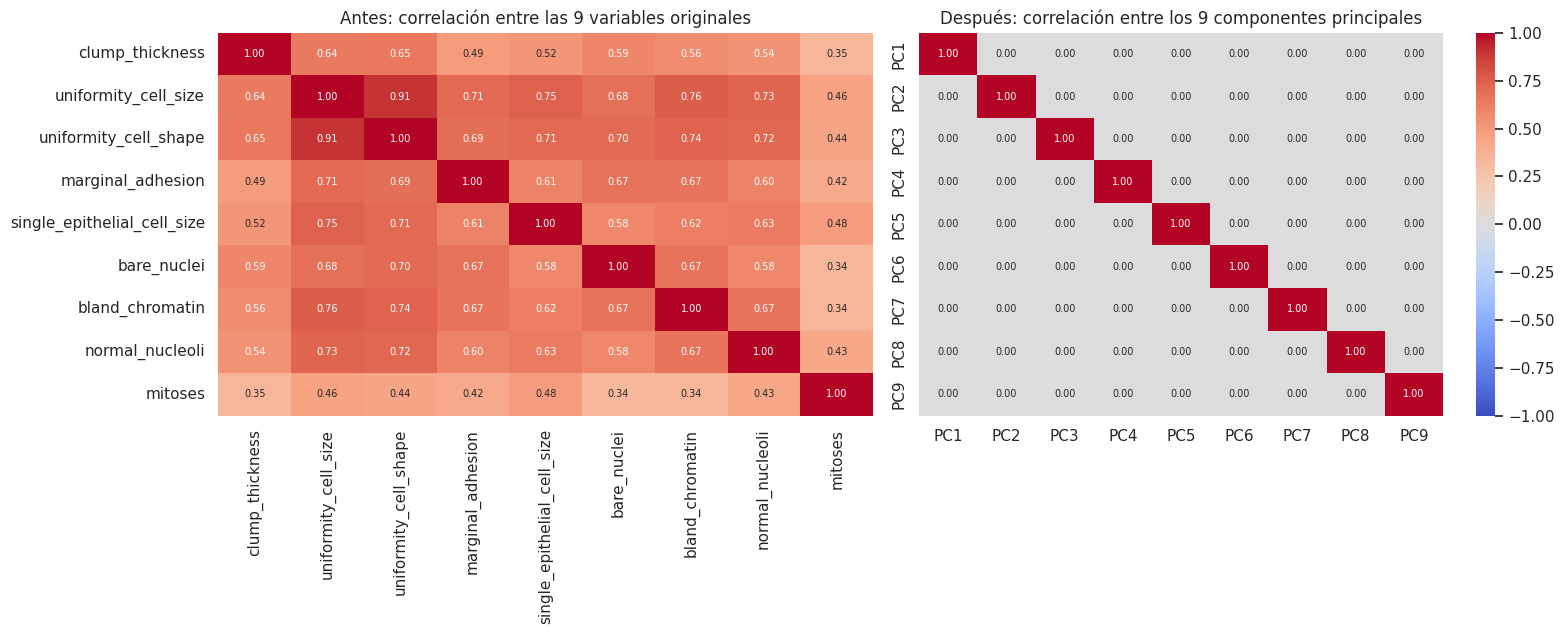

In [25]:
corr_antes = X.corr()
corr_despues = pd.DataFrame(componentes, columns=nombres_pc).corr().round(2) + 0.0   # +0.0 evita mostrar "-0.00"

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

sns.heatmap(corr_antes, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            annot_kws={"size": 7}, cbar=False, ax=axes[0])
axes[0].set_title("Antes: correlación entre las 9 variables originales")

sns.heatmap(corr_despues, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            annot_kws={"size": 7}, ax=axes[1])
axes[1].set_title("Después: correlación entre los 9 componentes principales")

plt.tight_layout()
plt.show()

A la izquierda, todas las variables están correlacionadas positivamente, algunas por encima de 0.7 (información repetida). A la derecha, los componentes no están correlacionados entre sí (ceros fuera de la diagonal), cada uno aporta información distinta. Ese es el mecanismo que permite descartar los últimos componentes sin perder casi nada.

## 6. Conclusiones
- **Datos:** 699 muestras y 9 características de 1 a 10. Las clases son 65.5 % benignas y 34.5 % malignas.
- **EDA:** las muestras malignas tienen valores más altos en las 9 características, y las variables están fuertemente correlacionadas entre sí.
- **Limpieza:** se eliminaron 8 registros idénticos, se imputaron 16 valores faltantes de `bare_nuclei` con la mediana (1) y se quitó la columna `id`. Resultado: 691 registros × 9 características + diagnóstico, sin faltantes.
- **PCA:** con 2 componentes se conserva el 74.2 % de la varianza; PC1 (65.6 %) actúa como un índice general de alteración y PC2 (8.6 %) recoge sobre todo `mitoses`. En el plano PC1-PC2 los dos diagnósticos quedan bastante separados, sin que el PCA haya usado la etiqueta.
- En este caso se decidió por imputar con la mediana, pero eliminar los 16 registros o imputar con otro criterio daría resultados muy ligeramente distintos.
- Las clases están desbalanceadas (65/35); no se hizo nada al respecto porque en este caso no se se optó por aumentar los datos.

## 7. Referencias

- Wolberg, W. H. y Mangasarian, O. L. (1990). *Multisurface method of pattern separation for medical diagnosis applied to breast cytology.* Proceedings of the National Academy of Sciences, U.S.A., 87, 9193-9196.
- Mangasarian, O. L. y Wolberg, W. H. (1990). *Cancer diagnosis via linear programming.* SIAM News, 23(5), 1 y 18.
- Archivo de descripción `breast-cancer-wisconsin.names` (University of Wisconsin Hospitals, Madison; donante: Olvi Mangasarian, 1992). Citación solicitada por los autores en ese mismo archivo.